In [3]:
# Imports

import tensorflow as tf
from tensorflow import keras, GradientTape
from keras import layers, Sequential, Model
from keras.datasets import mnist
from keras.layers import Dense
from tensorflow import cast, float32
import numpy as np
from tensorflow import losses

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

def evaluate_classification(y_true, y_pred, output_prefix="model_eval"):

    # =========================
    # Preparación de etiquetas
    # =========================
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_flat = y_true.reshape(-1)

    num_classes = y_pred.shape[1]

    # =========================
    # Métricas principales
    # =========================
    accuracy = accuracy_score(y_true_flat, y_pred_classes)
    precision_macro = precision_score(y_true_flat, y_pred_classes, average="macro")
    recall_macro = recall_score(y_true_flat, y_pred_classes, average="macro")
    f1_macro = f1_score(y_true_flat, y_pred_classes, average="macro")

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    loss = loss_fn(y_true, y_pred).numpy()

    top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, num_classes))
    top5.update_state(y_true, y_pred)
    top5_acc = top5.result().numpy()

    # =========================
    # Guardar métricas en CSV
    # =========================
    metrics_dict = {
        "Accuracy": accuracy,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "Loss": loss,
        "Top5_accuracy": top5_acc
    }

    df_metrics = pd.DataFrame([metrics_dict])
    df_metrics.to_csv(f"{output_prefix}_metrics.csv", index=False)

    # =========================
    # Classification Report
    # =========================
    report = classification_report(y_true_flat, y_pred_classes, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(f"{output_prefix}_classification_report.csv")

    # =========================
    # Matriz de Confusión
    # =========================
    cm = confusion_matrix(y_true_flat, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix.svg", format="svg")
    plt.close()

    # =========================
    # Matriz Normalizada
    # =========================
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix_normalized.svg", format="svg")
    plt.close()

    plt.figure(figsize=(10,4))

    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(predict_x[i])
        plt.title(f"True: {y_true_flat[i]}\nPred: {y_pred_classes[i]}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"{output_prefix}_ten_images.svg", format="svg")
    plt.close()

    print("Evaluación completada y archivos guardados.")
    print(metrics_dict)

    return metrics_dict


In [28]:
class GA_FeatureSelection():
    def __init__(self,
                 loss_fn,
                 eval_model,
                 pop_size=20,
                 generations=30,
                 crossover_rate=0.9,
                 mutation_rate=0.1,
                 alpha=0.9,      # peso del error
                 beta=0.1,       # penalización por #features
                 elitism=True):
        self.loss_fn = loss_fn
        self.eval_model = eval_model
        self.pop_size = pop_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.alpha = alpha
        self.beta = beta
        self.elitism = elitism

        self.history = {
            "Best": [],
            "Features": []
        }

    # Mutacion del indivudo seleccionado desde el crossover
    def mutate(self, individual):
        mutated = individual.copy()

        for gene_idx in range(len(mutated)):
            if np.random.rand() < self.mutation_rate:
                mutated[gene_idx] = 1 - mutated[gene_idx]

        return mutated

    def crossover(self, parent_a, parent_b):
        gene_mask = np.random.rand(len(parent_a)) < 0.5 
        return np.where(gene_mask, parent_a, parent_b)

    # Seleccion de un solo individuo por torneo
    def tournament_selection(self, population, fitness_scores, k=3):
        idx = np.random.choice(len(population), k, replace=False)
        winner = idx[np.argmin(fitness_scores[idx])]
        return population[winner]

    # No se si mi funcion fitness esta bien, pero es lo que saque con lo que pude
    # Categorical cross-entropy la agarre porque de acuerdo a google se suele usar cuando se tienen mas de dos clases y tambien porque funciona con softmax
    def fitness(self, individual, features, y):
        if individual.sum() == 0:
            return np.inf
        
        mask = tf.cast(individual, tf.float32)
        mask = tf.reshape(mask, (1, -1))

        feats_selected = features * mask
        logits = self.eval_model(feats_selected, training=False)
        
        loss = self.loss_fn(y, logits).numpy()

        penalty = individual.sum() / features.shape[1]

        return self.alpha * loss + self.beta * penalty

    def call_best_mask_GA(self, features, y, best_mask=None):
        num_features = features.shape[1]
        if best_mask is None:
            population = np.random.randint(
                0, 2,
                size=(self.pop_size, num_features)
            )
        else:
            population = np.random.randint(
                0, 2,
                size=(self.pop_size, num_features)
            )
        
        best_global = None
        best_fitness = np.inf

        for gen in range(self.generations):
            fitness_scores = np.array([
                self.fitness(individual, features, y) for individual in population 
            ])
            best_idx = np.argmin(fitness_scores)
            if fitness_scores[best_idx] < best_fitness:
                best_fitness = fitness_scores[best_idx]
                best_global = population[best_idx].copy()

            new_population = []

            if self.elitism:
                new_population.append(best_global.copy())
            
            while len(new_population) < self.pop_size:
                parent_a = self.tournament_selection(population, fitness_scores, 5)
                parent_b = self.tournament_selection(population, fitness_scores, 5)
                if np.random.rand() < self.crossover_rate:
                    child = self.crossover(parent_a, parent_b)
                else:
                    child = parent_a.copy()
                
                child = self.mutate(child)
                new_population.append(child)

            population = np.array(new_population)
            #print(f"Gen {gen:02d} | "
            #      f"Best: {best_fitness:.4f} | "
            #      f"Features: {best_global.sum()}")
            self.history["Best"].append(float(best_fitness))
            self.history["Features"].append(float(best_global.sum()))

        return best_global

In [65]:
class myModel_fs():
    def __init__(self, feature_extractor, classifier, batch_size=32):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier = classifier
        self.batch_size = batch_size

        self.optimizer = keras.optimizers.Adam()
        self.loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
        self.acc_metric = keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        
        self.GA_FeatureSelection = GA_FeatureSelection(
            loss_fn=self.loss_fn,
            eval_model=self.classifier,
            beta=0)
        

        self.best_mask = None
        self.pruned = False


    def train_epoch(self, x, y, num_epochs, prune_epoch=10):
        dataset = tf.data.Dataset.from_tensor_slices((x, y)).batch(self.batch_size)
        for epoch in range(num_epochs):    

            for xb, yd in dataset:
                with tf.GradientTape() as tape:
                    feats = self.feature_extractor(xb, training=True)
                    logits = self.classifier(feats, training=True)
                    loss = self.loss_fn(yd, logits)
                
                train_vars = (
                    self.feature_extractor.trainable_variables +
                    self.classifier.trainable_variables
                )
                grads = tape.gradient(loss, train_vars)
                self.optimizer.apply_gradients(zip(grads, train_vars))

            if epoch == prune_epoch and not self.pruned:
                print("\nRunning GA for pruning...\n")

                features = self.feature_extractor(x, training=False)
                self.best_mask = self.GA_FeatureSelection.call_best_mask_GA(
                    features,
                    y
                )

                self.pruned = True                
                self.optimizer = keras.optimizers.Adam(1e-3)
            
            feats = self.feature_extractor(x, training=False)
            logits = self.classifier(feats, training=False)

            self.acc_metric.update_state(y, logits)
            acc = float(self.acc_metric.result())
            self.acc_metric.reset_state()

            print(f"Epoch {epoch+1} | loss={loss:.4f} | acc={acc:.4f}")

        return acc


    def predict(self, x):
        out = []
        for xb in x:
            outX = []
            feats = self.feature_extractor(x, training=True)
            logits = self.classifier(feats, training=False)
            outX.append(tf.argmax(logits, axis=1))
        return tf.concat(out, axis=0)


In [53]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

In [66]:
cnn = Sequential([
        layers.Input(shape = (28, 28, 1)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten()
])

mlp = Dense(10, activation='softmax', name='classifier')

In [68]:
model = myModel_fs(cnn, mlp)
model.train_epoch(x_test, y_test, 10, prune_epoch=1)

    

Epoch 1 | loss=0.0010 | acc=0.9828

Running GA for pruning...

Epoch 2 | loss=0.0000 | acc=0.9955
Epoch 3 | loss=0.0000 | acc=0.9921
Epoch 4 | loss=0.0000 | acc=0.9938
Epoch 5 | loss=0.0000 | acc=0.9981
Epoch 6 | loss=0.0000 | acc=0.9983
Epoch 7 | loss=0.0000 | acc=0.9998
Epoch 8 | loss=0.0000 | acc=0.9930
Epoch 9 | loss=0.0000 | acc=0.9978
Epoch 10 | loss=0.0000 | acc=0.9993


0.9993000030517578

In [73]:
from sklearn.preprocessing import OneHotEncoder # type: ignore

# Queria hacer esto con tensorflow pero preferi hacerlo con
# sklearn porque se me hizo sencillo y aun no entendi bien como
# lo hace tensorflow
enc = OneHotEncoder()
# Sacamos las imagenes y labels para pruebas
predict_x = x_train[0:100]
y_true =  y_train[0:100]

# Train labels
y_true = y_true[..., np.newaxis]
transformed = enc.fit_transform(y_true)
train_labels_encoded = transformed.toarray()

In [74]:
fe = model.feature_extractor.predict(predict_x)
mask = model.best_mask
feats = fe * tf.cast(mask, tf.float32)
y_pred = model.classifier(fe, training=False)



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


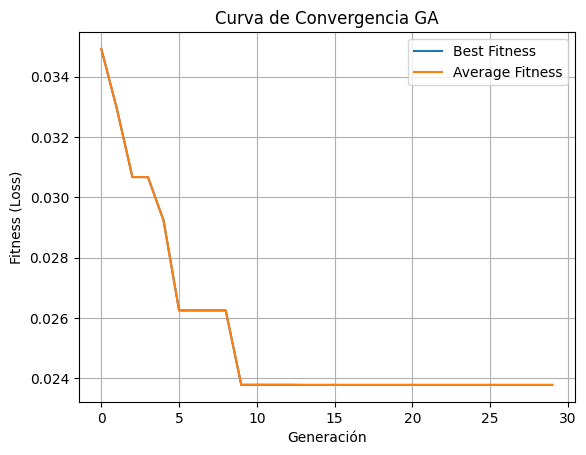

In [71]:
ga = model.GA_FeatureSelection.history
plt.figure()
plt.plot(ga["Best"])
plt.plot(ga["Best"])

plt.xlabel("Generación")
plt.ylabel("Fitness (Loss)")
plt.title("Curva de Convergencia GA")

plt.legend(["Best Fitness", "Average Fitness"])
plt.grid(True)

plt.show()

In [69]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

def evaluate_classification(y_true, y_pred, output_prefix="model_eval"):

    # =========================
    # Preparación de etiquetas
    # =========================
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_flat = y_true.reshape(-1)

    num_classes = y_pred.shape[1]

    # =========================
    # Métricas principales
    # =========================
    accuracy = accuracy_score(y_true_flat, y_pred_classes)
    precision_macro = precision_score(y_true_flat, y_pred_classes, average="macro")
    recall_macro = recall_score(y_true_flat, y_pred_classes, average="macro")
    f1_macro = f1_score(y_true_flat, y_pred_classes, average="macro")

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    loss = loss_fn(y_true, y_pred).numpy()

    top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, num_classes))
    top5.update_state(y_true, y_pred)
    top5_acc = top5.result().numpy()

    # =========================
    # Guardar métricas en CSV
    # =========================
    metrics_dict = {
        "Accuracy": accuracy,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "Loss": loss,
        "Top5_accuracy": top5_acc
    }

    df_metrics = pd.DataFrame([metrics_dict])
    df_metrics.to_csv(f"{output_prefix}_metrics.csv", index=False)

    # =========================
    # Classification Report
    # =========================
    report = classification_report(y_true_flat, y_pred_classes, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(f"{output_prefix}_classification_report.csv")

    # =========================
    # Matriz de Confusión
    # =========================
    cm = confusion_matrix(y_true_flat, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix.svg", format="svg")
    plt.close()

    # =========================
    # Matriz Normalizada
    # =========================
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix_normalized.svg", format="svg")
    plt.close()

    plt.figure(figsize=(10,4))

    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(predict_x[i])
        plt.title(f"True: {y_true_flat[i]}\nPred: {y_pred_classes[i]}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"{output_prefix}_ten_images.svg", format="svg")
    plt.close()

    print("Evaluación completada y archivos guardados.")
    print(metrics_dict)

    return metrics_dict


In [77]:
fe = model.feature_extractor.predict(x_test)
y_pred = model.classifier(fe, training=False).numpy()

evaluate_classification(y_test, y_pred, output_prefix="CNN_FS_MLP")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Evaluación completada y archivos guardados.
{'Accuracy': 0.9993, 'Precision_macro': 0.9993083944076766, 'Recall_macro': 0.9992970365809375, 'F1_macro': 0.9993014604983725, 'Loss': np.float32(0.0020915563), 'Top5_accuracy': np.float32(1.0)}


{'Accuracy': 0.9993,
 'Precision_macro': 0.9993083944076766,
 'Recall_macro': 0.9992970365809375,
 'F1_macro': 0.9993014604983725,
 'Loss': np.float32(0.0020915563),
 'Top5_accuracy': np.float32(1.0)}

In [ ]:
def train_model(epochs, dataset, loss_fn, optimizer, feature_extractor, classifier):
    for epoch in range(epochs):
        with GradientTape() as tape:
            features = feature_extractor(x, training=True)
            preds = classifier(features, training=False)
            loss = loss_fn(y, preds)
        training_vars = feature_extractor.trainable_variables
        gradients = tape.gradient(loss, training_vars)
    optimizer.apply_gradients(zip(gradients, training_vars))
    w = classifier.get_weights()[0]
    print(w.shape)
    ga_update(features.numpy(), y.numpy(), classifier)
    print(f"Epoch{epoch}")